# Bistro Introduction

_Updated April 15, 2025_

In this notebook we demonstrate how to perform a difference-in-differences (DiD) analysis using the bistro package. Bistro simplifies Bayesian regression tasks by building on libraries like bambi (which itself uses PyMC and patsy) while also offering useful visualization tools.

In our example we simulate data reflecting the effect of provider education sessions on emergency department visits for behavioral health/SUD reasons. We expect ED visits to decrease after the intervention. Later, we also show an optional matching procedure using nearest neighbor matching.

This notebook is designed for colleagues coming from a frequentist background, and it explains the process step-by-step.  

_Note: I have written this notebook to be run from Google Colab_

First, we will ensure that required packages are installed.  This includes the bistro package, which is currently in development on D.M. Burt's GitHub repository for bistro.

In [ ]:
!pip install --upgrade git+https://github.com/dmburt/bistro.git watermark

In [2]:
import numpy as np
import pandas as pd
from bistro import BModel

from matplotlib import pyplot as plt
from matplotlib import rcParams


from IPython import display
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


def set_style():
    font = {'family' : 'Liberation Sans',
            #'size'   : 16
           }
    math_fontfamily = {'family' : 'Liberation Sans',
                      }
    plt.style.use(['seaborn-v0_8-whitegrid', 'seaborn-v0_8-paper'])

set_style()


rcParams["mathtext.fontset"] = 'custom'
rcParams["mathtext.rm"] = 'Liberation Sans'
rcParams["mathtext.it"] = 'Liberation Sans'
rcParams["mathtext.sf"] = 'Liberation Sans'
rcParams['font.cursive'] = 'Liberation Sans'

import watermark

%matplotlib inline
%config InlineBackend.figure_format='retina'


## Make test data

The synthetic dataset includes:

TREAT: A binary indicator (1 = treatment, 0 = control)

POST: A binary indicator for the post-intervention period

Y: The outcome variable (average ED visits per person per month over the period)

age: An additional covariate (for optional matching)

In [3]:
# Set seed for reproducibility
np.random.seed(42)

# Number of observations per group/time period
n_per_group = 100

# --- Control Group ---
# Pre-intervention data (baseline ED visits ~10)
control_pre = pd.DataFrame({
    'TREAT': 0,
    'POST': 0,
    'Y': np.random.normal(loc=10, scale=2, size=n_per_group)
})
# Post-intervention data (small natural decline, e.g., ED visits ~9)
control_post = pd.DataFrame({
    'TREAT': 0,
    'POST': 1,
    'Y': np.random.normal(loc=9, scale=2, size=n_per_group)
})

# --- Treatment Group ---
# Pre-intervention data (similar baseline)
treat_pre = pd.DataFrame({
    'TREAT': 1,
    'POST': 0,
    'Y': np.random.normal(loc=10, scale=2, size=n_per_group)
})
# Post-intervention data (larger reduction due to provider education, e.g., ED visits ~7)
treat_post = pd.DataFrame({
    'TREAT': 1,
    'POST': 1,
    'Y': np.random.normal(loc=7, scale=2, size=n_per_group)
})

# Combine all data into a single DataFrame
df = pd.concat([control_pre, control_post, treat_pre, treat_post], ignore_index=True)

# (Optional) Add a covariate (e.g., age) to later demonstrate matching
df['age'] = np.random.randint(30, 70, size=len(df))

# Display the first few rows of the dataset
df.head()

,TREAT,POST,Y,age
0,0,0,10.993428,64
1,0,0,9.723471,30
2,0,0,11.295377,50
3,0,0,13.046060,35
4,0,0,9.531693,57


## 2. Fitting the Difference-in-Differences Model

Next, we create a BModel instance from bistro. We split the data into treatment and control groups and then fit a DiD regression model using a patsy-style formula. In our formula:

TREAT captures the difference between groups,

POST captures the time effect, and

TREAT * POST represents the interaction term—the DiD effect.

This is where the model-fitting is done, so this may take a couple of minutes.  Bistro uses the [PyMC](https://www.pymc.io/welcome.html) and [bambi](https://bambinos.github.io/bambi/) libraries to make this work.

In [4]:
# Separate the data by treatment group
df_treat = df[df['TREAT'] == 1]
df_control = df[df['TREAT'] == 0]

# Create a BModel instance, specifying the treatment variable
model = BModel(data_treat=df_treat, data_control=df_control, treat_var='TREAT')

# Fit the difference-in-differences regression model
model.fit(reg_formula='Y ~ TREAT + POST + TREAT*POST')

Output()

## 3. Model Diagnostics: Trace Plots

It is important to check the convergence of the Bayesian model’s posterior distributions. The trace plot below shows the sampling behavior for each parameter.

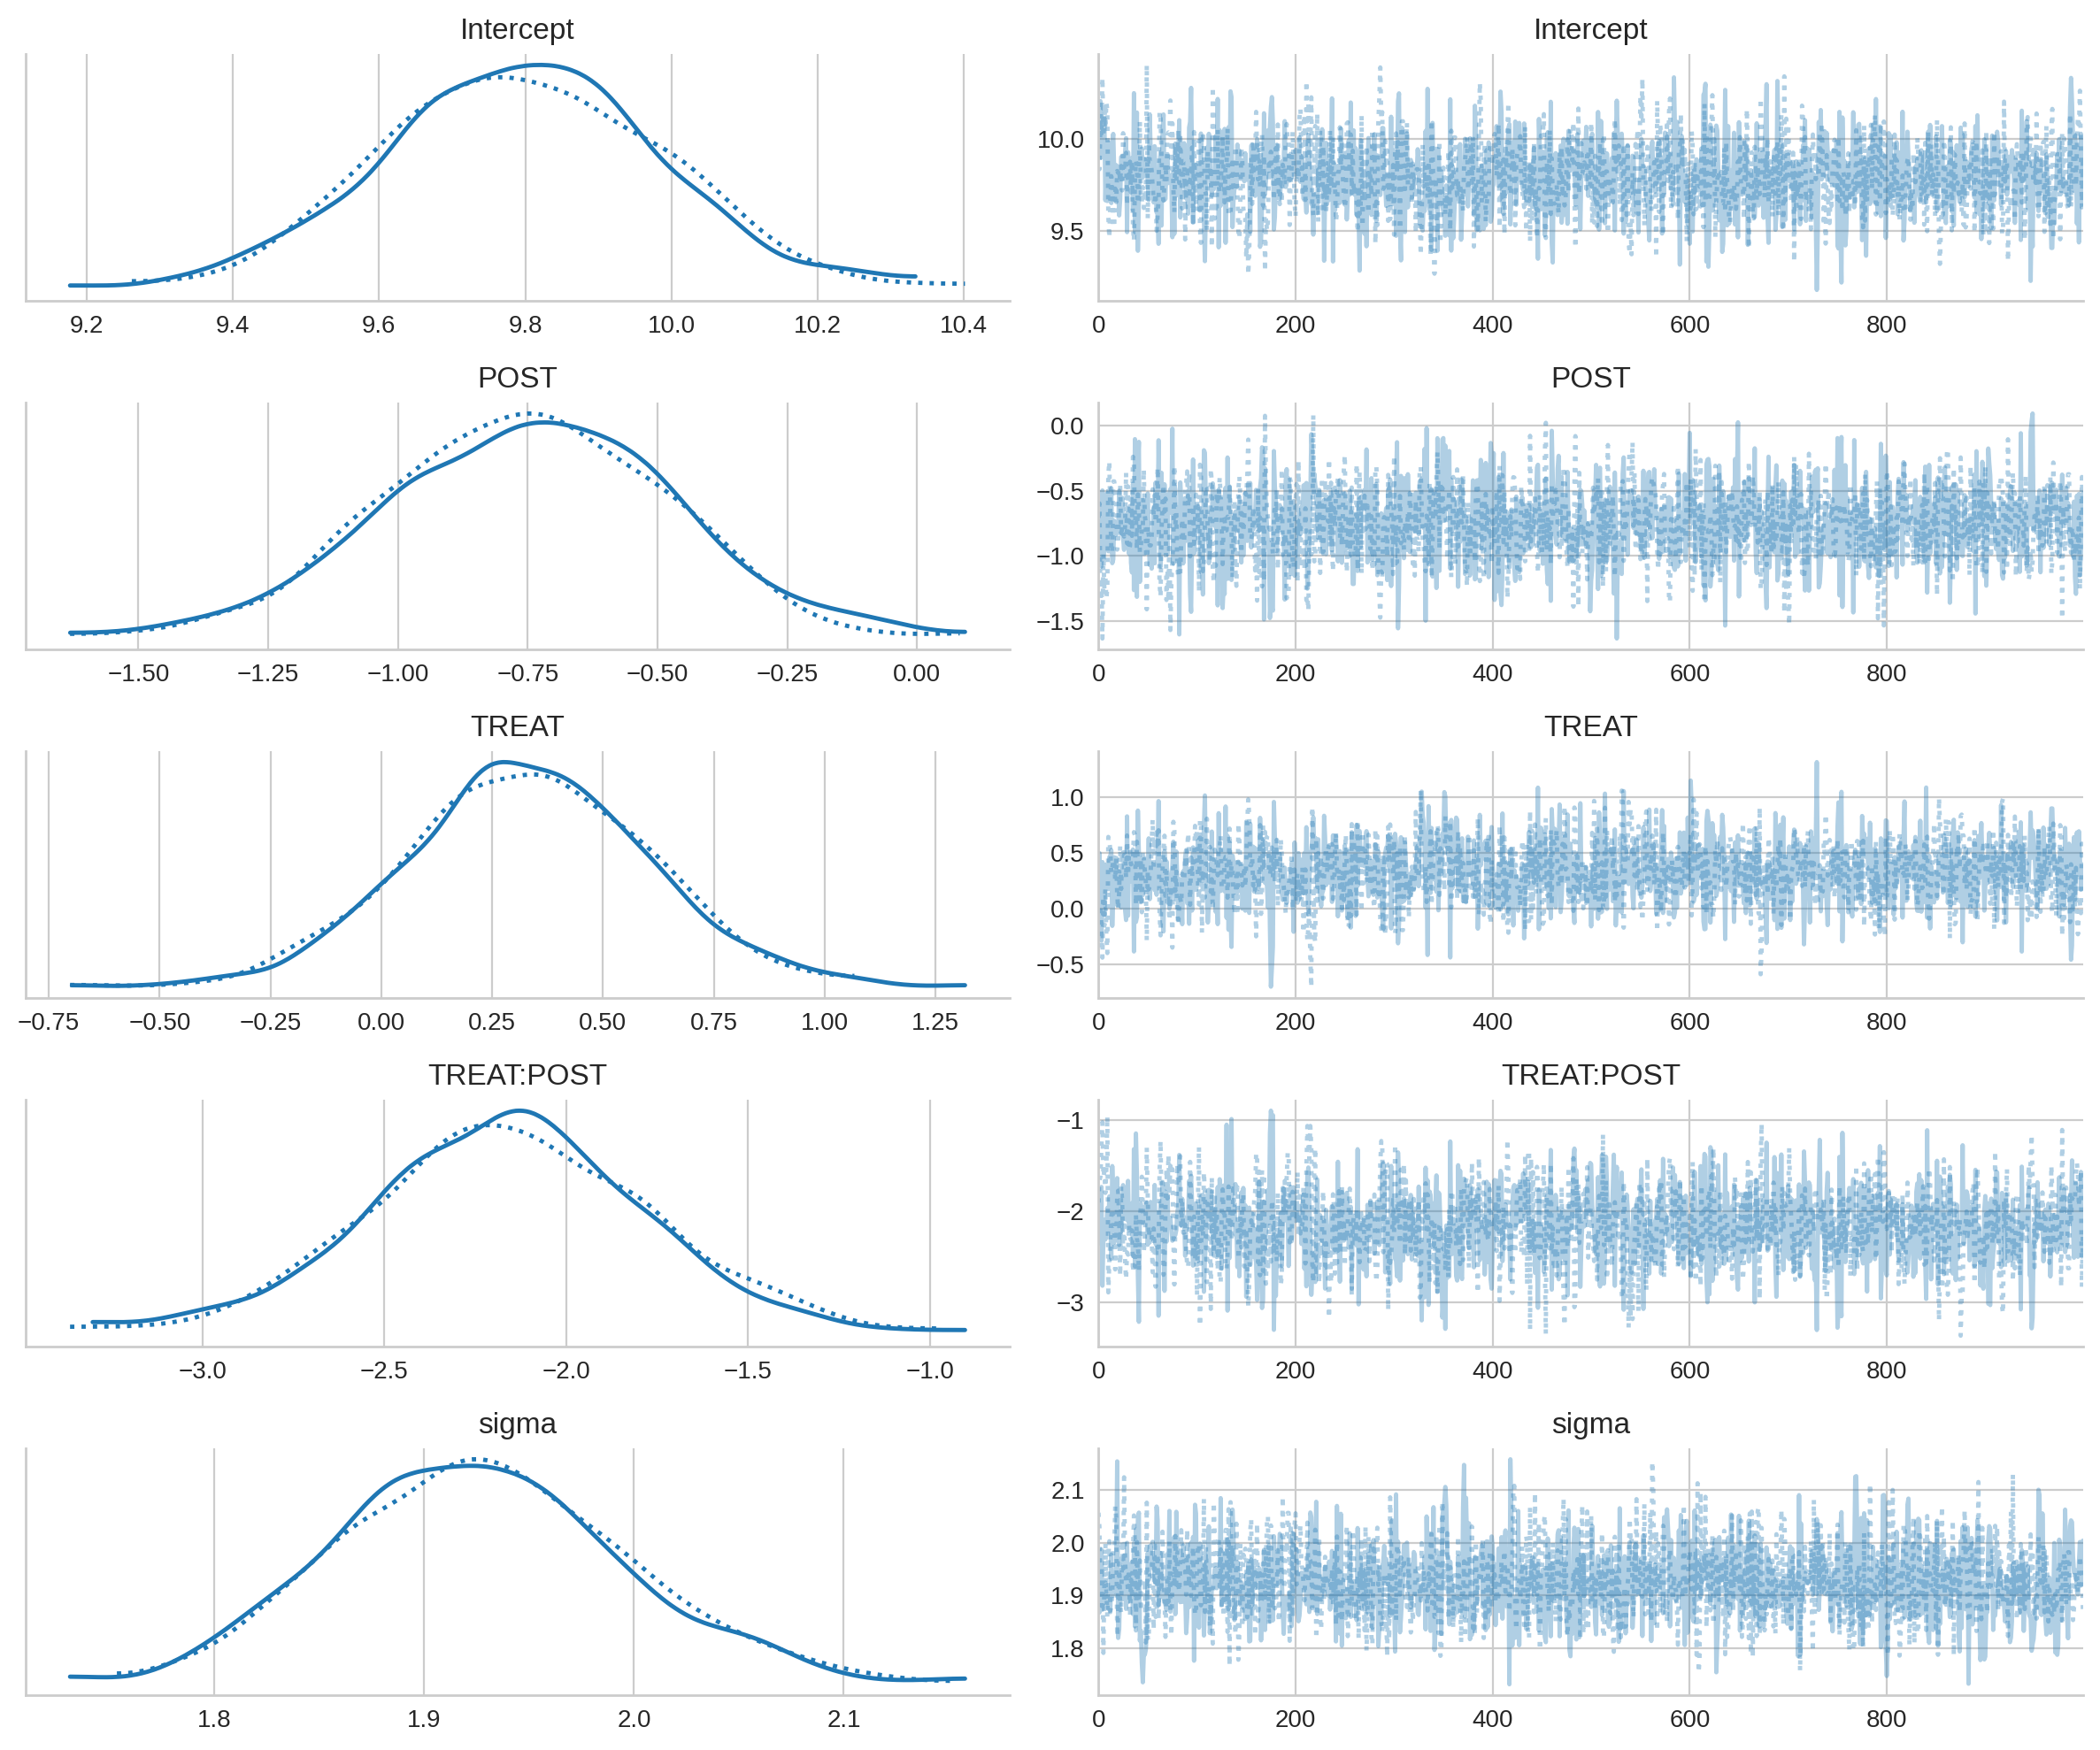

In [5]:
model.plot_trace()

## 4. Visualizing the DiD Effects

This cell visualizes the estimated regression lines for both the treatment (factual and counterfactual) and control groups. On the left, you’ll see the fitted trajectories, and on the right, the highest-density interval (HDI) for the DiD effect (the interaction term). The plotted DiD estimate quantifies the impact of the intervention.

In the plot on the left:

The treatment factual line represents the observed outcomes in the treatment group post-intervention.

The treatment counterfactual line shows the estimated trajectory if the intervention had not occurred.

The control line represents the control group’s outcome over time.

The right-hand plot displays the highest-density interval for the interaction (DiD) term. If the interval does not include zero, it suggests a statistically meaningful effect of the intervention. In our simulation, you should see a pronounced decrease in ED visits among the treatment group following the intervention compared to the control group.

This example demonstrates how Bayesian regression methods can be presented in a framework that is accessible to those with a frequentist background.

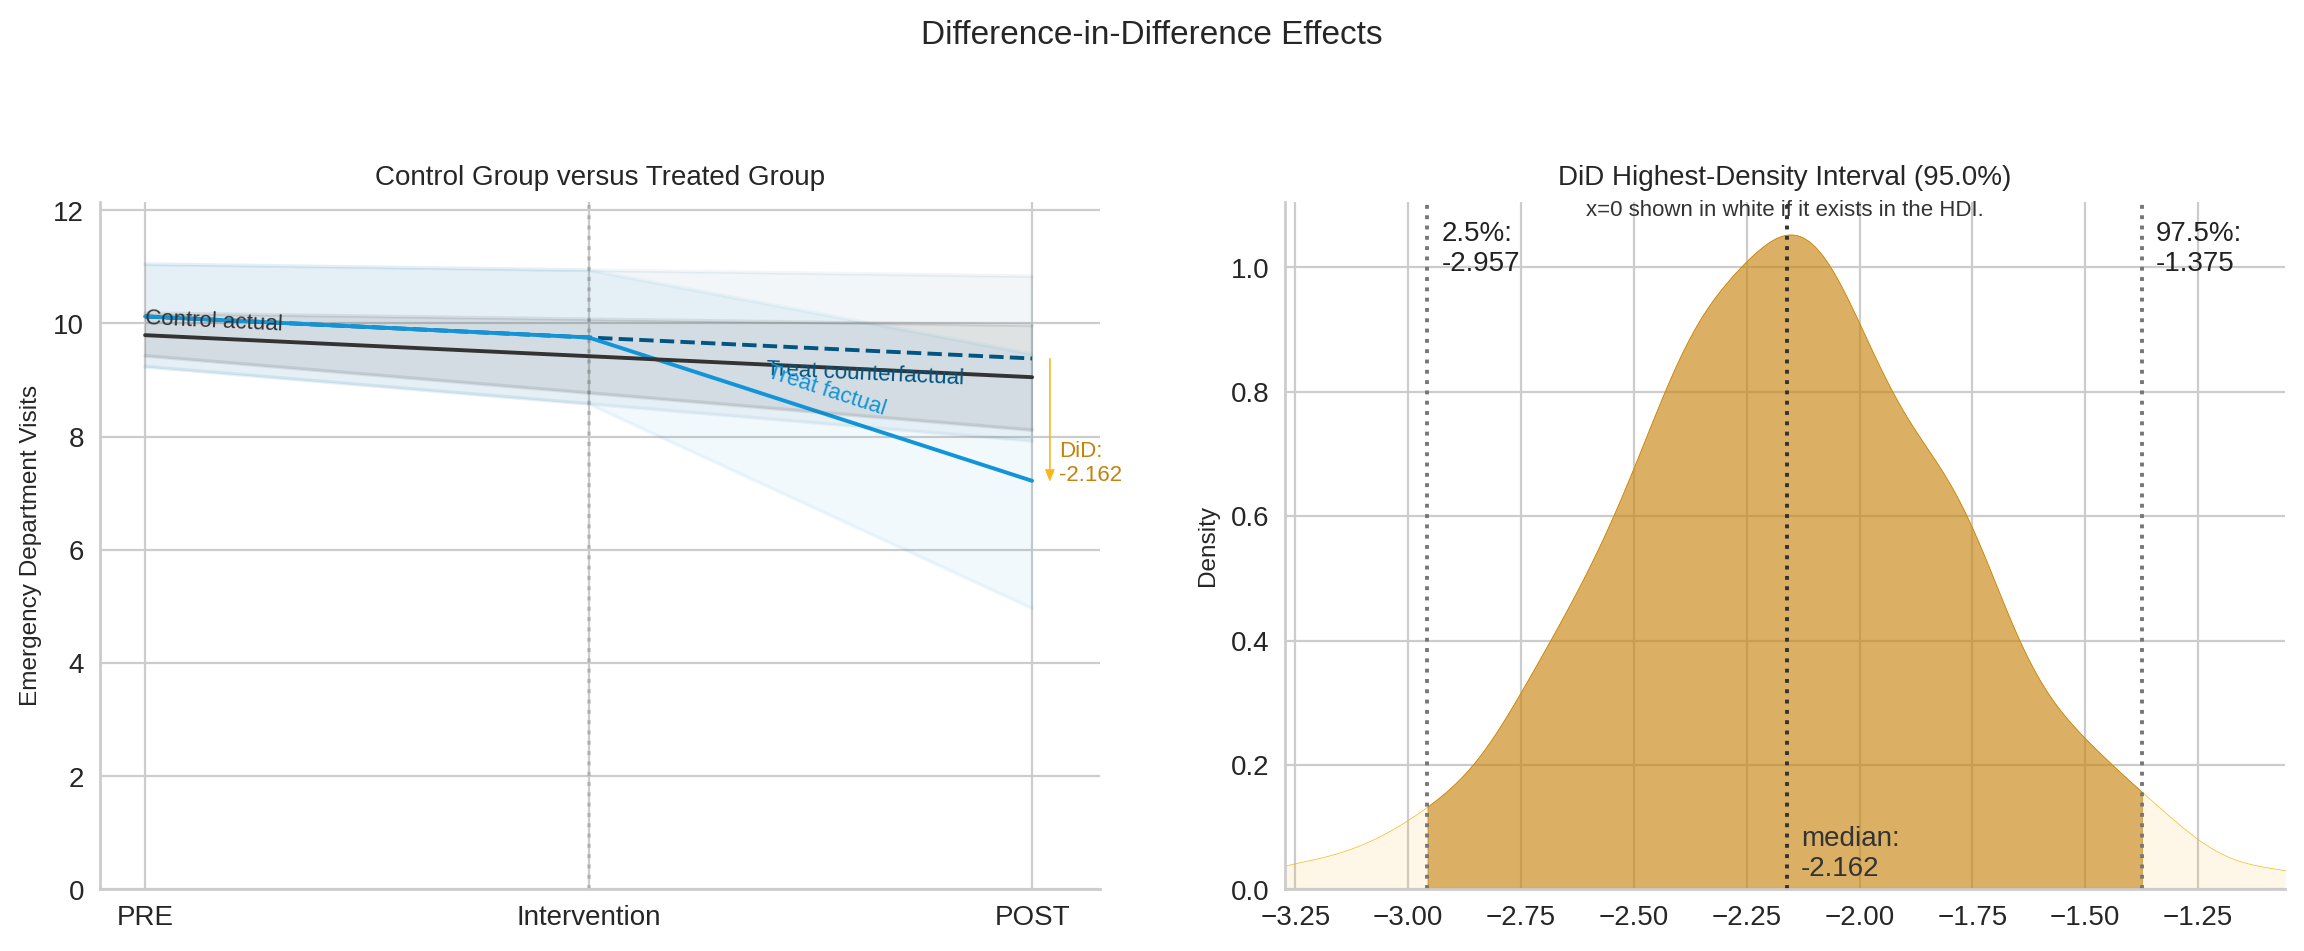

In [6]:
model.plot_effects(model,
                   line_type='single',
                   split_point=0.5,
                   figsize=(12,5),
                   hdi=0.95,
                   suptitle_fontsize=12,
                   title_fontsize=10,
                   label_fontsize=8,
                   tick_fontsize=10,
                   show_did=True,
                   y_label='Emergency Department Visits',
                   y_pad=(0.2, 0.35, 0.2),
                   labels_above_line=(True, False, True)
                  )

## 5. Get a summary table

Another thing you can do is to get a summary table of fitted parameters from the model (usually classically referred to as "Table 2" of many research papers).  To do this easily, we can use the Arviz package.

In a classical (frequentist) paper, “Table 2” usually lists your regression coefficients, standard errors, confidence intervals, and p‑values.  In the Bayesian world we can produce an analogous table of **posterior summaries** using ArviZ’s `az.summary()`.  By default you’ll get:

- **mean**: the posterior mean (our point estimate, analogous to the frequentist coefficient).  
- **sd**: the posterior standard deviation (uncertainty around the point estimate).  
- **hdi_2.5%** and **hdi_97.5%**: the lower and upper bounds of the 95% highest‑density credible interval (Bayesian analog of a confidence interval).  
- **mcse_mean** / **mcse_sd**: the Monte Carlo standard error of the mean/SD estimates, reflecting how much sampling noise remains in your MCMC draws.  
- **ess_bulk** / **ess_tail**: effective sample sizes for the bulk and tails of each posterior—larger values (>200) indicate more precise estimates.  
- **r_hat**: the Gelman–Rubin convergence diagnostic; values very close to 1 (e.g. <1.01) indicate good convergence.

These columns let you both **quantify** your effect sizes and **diagnose** sampler performance.  You can customize and export the table for your manuscript, for example:


In [8]:
import arviz as az

az.summary(model.fitted_model)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,9.796,0.191,9.439,10.148,0.005,0.004,1502.0,1440.0,1.0
POST,-0.751,0.277,-1.274,-0.230,0.007,0.006,1648.0,1111.0,1.0
TREAT,0.329,0.271,-0.192,0.823,0.007,0.006,1375.0,1171.0,1.0
TREAT:POST,-2.163,0.395,-2.925,-1.400,0.011,0.009,1327.0,1301.0,1.0
sigma,1.927,0.068,1.804,2.060,0.002,0.002,1935.0,1181.0,1.0


## 6. (Optional) Matching Control Group Using Nearest Neighbors

Bistro also provides a nearest neighbor matching method to help select a control group that is more comparable to the treatment group on key covariates. Here we demonstrate matching on the 'age' variable. Matching can improve the balance between groups before fitting the DiD model.

After matching, we re-fit the DiD model and visualize the results again.


In [ ]:
# Apply nearest neighbor matching using the 'age' covariate.
model.match_control_nn(match_features=['age'], neighbors=1, scaling='minmax')

# Re-fit the model using the matched control group
model.fit(reg_formula='Y ~ TREAT + POST + TREAT*POST')

# Plot the DiD effects after matching
model.plot_effects(model,
                   line_type='single',
                   split_point=0.5,
                   figsize=(12,5),
                   hdi=0.95,
                   suptitle_fontsize=12,
                   title_fontsize=10,
                   label_fontsize=8,
                   tick_fontsize=10,
                   show_did=True,
                   y_label='Emergency Department Visits',
                   y_pad=(0.2, 0.35, 0.2),
                   labels_above_line=(True, False, True)
                  )

In [ ]:
import arviz as az

az.summary(model.fitted_model)